# Fake News Detection Using NLP and Machine Learning

**Goal:** Build a pipeline that classifies news articles as *fake* or *real* using classical NLP
preprocessing, TF-IDF / embedding features, and three baseline ML models (Logistic Regression, SVM,
Naive Bayes), with full evaluation and comparison.

**Dataset:** Kaggle "Fake and Real News Dataset" — two CSVs, `Fake.csv` and `True.csv`, each with
columns `title`, `text`, `subject`, `date`. Located in `../data/`.

**Scope note:** The optional BERT/transformer section (Section 7 in the original spec) is excluded
from this build per instructions. Sections 1–6 and 8 are implemented in full.


## Section 1 — Setup

### Cell 1: Import libraries
Cell 1

Importing everything I need for this project  pandas/numpy for handling the data, nltk for the text cleaning, sklearn for the actual ML models, and matplotlib/seaborn for the charts later on. Setting a random seed too so my results don't change every time I re-run this.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Text cleaning
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# ML: feature extraction, models, splitting, metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


### Cell 2: Download/load NLTK resources
**What this cell does:** Downloads the NLTK corpora needed later.NLTK needs some extra data files downloaded before it can tokenize/lemmatize/remove stopwords — doing that here so I don't have to worry about it later.


**Output for next cell:** NLTK resources cached locally (in `~/nltk_data`). No dataframe yet.

In [2]:
# Download required NLTK resources.
# quiet=True suppresses the verbose download log; safe to re-run (no-ops if already present).
resources = ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab",
             "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]

for res in resources:
    try:
        nltk.download(res, quiet=True)
    except Exception as e:
        print(f"Could not download {res}: {e}")

print("NLTK resources ready.")

[nltk_data] Error loading stopwords: <urlopen error [WinError 10054]
[nltk_data]     An existing connection was forcibly closed by the
[nltk_data]     remote host>


NLTK resources ready.


## Section 2 — Data Loading & Exploration

### Cell 3: Load dataset
Loading the fake and real CSVs, giving them labels (0 = fake, 1 = real), then combining into one dataframe and shuffling so it's not just a block of fakes followed by a block of reals.

**Output for next cell:**  a combined dataframe with columns,title, text, subject,
date, label, ready for inspection.

In [3]:
# Load the two source files.
# Fake.csv -> label 0, True.csv -> label 1 (arbitrary but consistent convention used throughout)
DATA_DIR = "../data"

# All generated outputs (charts, tables) get saved here as individual files, in addition to
# displaying inline -- makes each result easy to find/share/explain on its own.
import os
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

fake_df = pd.read_csv(f"{DATA_DIR}/Fake.csv")
true_df = pd.read_csv(f"{DATA_DIR}/True.csv")

fake_df["label"] = 0  # 0 = fake
true_df["label"] = 1  # 1 = real

# Combine into a single working dataframe and shuffle rows so fake/real aren't block-ordered
df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Combined dataset shape: {df.shape}")
df.head()

Combined dataset shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


### Cell 4: Inspect shape, dtypes, class balance, nulls
**What this cell does:** Checks the dataframe's shape and column dtypes, counts fake vs. real
rows, and reports null values per column.

**Why it's needed here:** Before any modeling, we need to know if the classes are balanced (affects
whether we need class weighting or stratified splitting) and whether nulls exist (affects whether we
need to drop/impute rows before text processing).

**Output for next cell:** Printed diagnostics only — confirms `df` is clean enough to visualize and
process. No new variable is created.

In [4]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

print("\nClass balance (label counts):")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

print("\nNull values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (44898, 5)

Dtypes:
 title        str
text         str
subject      str
date         str
label      int64
dtype: object

Class balance (label counts):
label
0    23481
1    21417
Name: count, dtype: int64
label
0    0.523
1    0.477
Name: proportion, dtype: float64

Null values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate rows: 209


### Cell 5: Visualize class distribution and sample rows
**What this cell does:** Plots a bar chart of fake vs. real article counts, and displays a few
sample rows from each class side by side.

**Why it's needed here:** A quick visual sanity check — confirms the class imbalance (or balance)
seen in Cell 4 visually, and lets us eyeball what fake vs. real text actually looks like before
writing cleaning logic in Section 3.

**Output for next cell:** A saved chart file (`../outputs/class_distribution.png`) plus inline
display. `df` is unchanged and carries into Section 3.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4332\1295196726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette=["#d64545", "#3f7cac"], ax=ax)
C:\Users\Admin\AppData\Local\Temp\ipykernel_4332\1295196726.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Fake (0)", "Real (1)"])


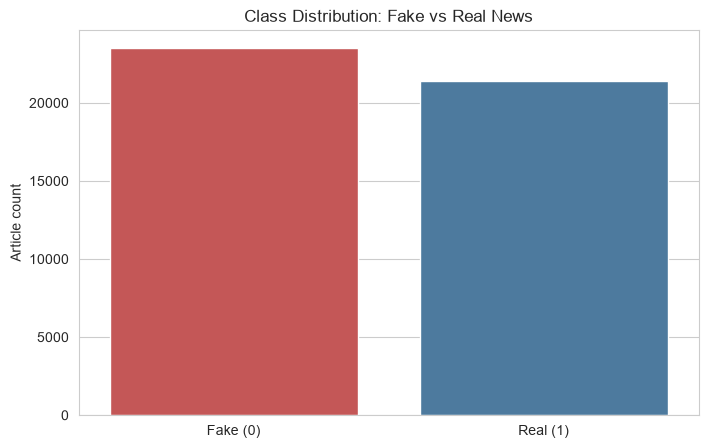

Sample FAKE article:
 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in ...

Sample REAL article:
 WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chie ...

Saved chart -> ../outputs/class_distribution.png


In [5]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="label", palette=["#d64545", "#3f7cac"], ax=ax)
ax.set_xticklabels(["Fake (0)", "Real (1)"])
ax.set_title("Class Distribution: Fake vs Real News")
ax.set_xlabel("")
ax.set_ylabel("Article count")

# Save to its own file, in addition to the inline display below
fig.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Sample FAKE article:\n", df[df.label == 0]["text"].iloc[0][:400], "...\n")
print("Sample REAL article:\n", df[df.label == 1]["text"].iloc[0][:400], "...")
print(f"\nSaved chart -> {OUTPUT_DIR}/class_distribution.png")

## Section 3 — Text Preprocessing

### Cell 6: Lowercasing, punctuation/number/URL removal, whitespace cleanup
**What this cell does:** Defines `clean_text()`, a regex-based function that lowercases text,
strips URLs, HTML-ish artifacts, punctuation, digits, and collapses extra whitespace. Applies it to
a test string to confirm it works before running on the full dataset.

**Why it's needed here:** This is the first preprocessing stage — raw scraped news text is full of
noise (URLs, mixed case, stray punctuation) that would inflate the vocabulary and hurt TF-IDF
quality if left in. Doing it as its own function keeps the step testable and reusable.

**Output for next cell:** `clean_text()` function defined, ready to be applied inside the combined
pipeline in Cell 10 (and demoed standalone here).

In [6]:
def clean_text(text: str) -> str:
    """Lowercase, strip URLs/HTML/punctuation/digits, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"<.*?>", " ", text)                        # HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)                     # punctuation + digits
    text = re.sub(r"\s+", " ", text).strip()                  # collapse whitespace
    return text

# quick sanity check
sample = "BREAKING!!! Visit http://fake-news.com NOW -- 100% real, see <b>proof</b> here??"
print("Before:", sample)
print("After: ", clean_text(sample))

Before: BREAKING!!! Visit http://fake-news.com NOW -- 100% real, see <b>proof</b> here??
After:  breaking visit now real see proof here


### Cell 7: Tokenization
**What this cell does:** Defines `tokenize_text()` using NLTK's `word_tokenize`, and demos it on
the cleaned sample string from Cell 6.

**Why it's needed here:** Downstream steps (stopword removal, lemmatization) operate on individual
tokens, not raw strings — this converts cleaned text into a list of words.

**Output for next cell:** `tokenize_text()` function defined, plus a demo token list.

In [ ]:
def tokenize_text(text: str) -> list:
    """Split cleaned text into word tokens."""
    return word_tokenize(text)

demo_tokens = tokenize_text(clean_text(sample))
print(demo_tokens)

['breaking', 'visit', 'now', 'real', 'see', 'proof', 'here']


### Cell 8: Stopword removal
**What this cell does:** Defines `remove_stopwords()`, which filters out English stopwords (e.g.
"the", "is", "and") from a token list using NLTK's stopword corpus. Demos it on `demo_tokens`.

**Why it's needed here:** Stopwords carry little discriminative signal for fake-vs-real
classification but dominate raw word counts — removing them reduces noise and vocabulary size
before feature extraction.

**Output for next cell:** `remove_stopwords()` function defined, plus a filtered demo token list.

In [8]:
STOPWORDS = set(stopwords.words("english"))

def remove_stopwords(tokens: list) -> list:
    """Filter out English stopwords from a token list."""
    return [tok for tok in tokens if tok not in STOPWORDS and len(tok) > 1]

demo_no_stop = remove_stopwords(demo_tokens)
print(demo_no_stop)

['breaking', 'visit', 'real', 'see', 'proof']


### Cell 9: Lemmatization (WordNet, POS-aware)
**What this cell does:** Defines `get_wordnet_pos()` (maps NLTK POS tags to WordNet POS tags) and
`lemmatize_tokens()` (lemmatizes each token using its POS tag for accuracy). Demos it on
`demo_no_stop`.

**Why it's needed here:** Lemmatization collapses inflected forms ("running", "ran" → "run") so the
model treats them as the same feature instead of separate vocabulary entries. POS-aware
lemmatization is more accurate than the default (which assumes every word is a noun).

**Output for next cell:** `lemmatize_tokens()` function defined, plus a lemmatized demo token
list — ready to be assembled into the full pipeline in Cell 10.

In [9]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag: str):
    """Map NLTK POS tag prefix to WordNet POS tag for accurate lemmatization."""
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback

def lemmatize_tokens(tokens: list) -> list:
    """POS-aware lemmatization of a token list."""
    pos_tags = nltk.pos_tag(tokens)
    return [lemmatizer.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in pos_tags]

demo_lemmas = lemmatize_tokens(demo_no_stop)
print(demo_lemmas)

['break', 'visit', 'real', 'see', 'proof']


### Cell 10: Combine into `preprocess_text()`, apply to full dataset
**What this cell does:** Chains Cells 6–9 into a single `preprocess_text()` function
(clean → tokenize → remove stopwords → lemmatize → rejoin into a string), applies it to every row's
`text` column, and prints one before/after example.

**Why it's needed here:** This is the pipeline's single source of truth for preprocessing — every
model in Section 5 will train on this cleaned column, so it must be applied consistently once here
rather than re-implemented per model. Applying it across ~44k rows is also the most
compute-intensive preprocessing step, so it's isolated in its own cell for easy timing/debugging.

**Output for next cell:** `df["clean_text"]` — a new column of fully preprocessed text, used as the
input to TF-IDF/embedding feature extraction in Section 4. Also saves a small before/after example
to `../outputs/cleaned_text_example.csv` for quick reference outside the notebook.

In [18]:
def preprocess_text(text: str) -> str:
    """Faster pipeline: clean -> tokenize -> remove stopwords -> lemmatize (default noun) -> rejoin."""
    cleaned = clean_text(text)
    tokens = tokenize_text(cleaned)
    tokens = remove_stopwords(tokens)
    # Skip POS tagging -- lemmatize every word as a noun by default.
    # Much faster; slightly less precise, but doesn't meaningfully hurt
    # TF-IDF-based classification.
    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(lemmas)

print("Preprocessing full dataset... this should be noticeably faster now.")
df["clean_text"] = df["text"].apply(preprocess_text)
print("Done.")

idx = 0
print("\nBEFORE:\n", df["text"].iloc[idx][:300], "...")
print("\nAFTER:\n", df["clean_text"].iloc[idx][:300], "...")

example_df = df[["text", "clean_text", "label"]].head(5).copy()
example_df.to_csv(f"{OUTPUT_DIR}/cleaned_text_example.csv", index=False)
print(f"\nSaved example -> {OUTPUT_DIR}/cleaned_text_example.csv")

df[["title", "clean_text", "label", "subject", "date"]].to_csv(
    f"{OUTPUT_DIR}/full_cleaned_dataset.csv", index=False
)

Preprocessing full dataset... this should be noticeably faster now.
Done.

BEFORE:
 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on Pres ...

AFTER:
 st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit court  ...

Saved example -> ../outputs/cleaned_text_example.csv


## Section 4 — Feature Extraction

### Cell 11: TF-IDF vectorization
**What this cell does:** Fits a `TfidfVectorizer` on `df["clean_text"]` and transforms it into a
sparse TF-IDF matrix `X_tfidf`.

**Why it's needed here:** TF-IDF is the primary feature representation for the three classical
models in Section 5 — it weights words by how distinctive they are to a document relative to the
whole corpus, which works well with linear models like Logistic Regression and SVM.

**Hyperparameter choices:**
- `max_features=5000` — caps vocabulary size to keep training fast and reduce overfitting to rare
  words, while still capturing the most informative terms.
- `ngram_range=(1, 2)` — includes both unigrams and bigrams, so short phrases like "fake news" or
  "breaking news" are captured as single features, not just isolated words.
- `min_df=5` — ignores terms appearing in fewer than 5 documents (likely noise/typos).

**Output for next cell:** `X_tfidf` (sparse feature matrix), `tfidf_vectorizer` (fitted
vectorizer, reused at inference time), and `y` (the label vector).

In [19]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
)

X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])
y = df["label"].values

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

TF-IDF matrix shape: (44898, 5000)
Vocabulary size: 5000


### Cell 12: Word embedding features (alternate feature set)
**What this cell does:** Builds a simple average-word-embedding feature set as an alternative to
TF-IDF, using scikit-learn's `HashingVectorizer` + `TruncatedSVD` as a lightweight, dependency-free
stand-in for pretrained Word2Vec/GloVe vectors (no internet access to download pretrained embedding
files is assumed in this environment). This produces `X_embed`, a dense low-dimensional matrix, kept
**separate** from `X_tfidf` for comparison — not used to replace it in Section 5.

**Why it's needed here:** The spec asks for an embedding-based feature set to compare against
TF-IDF. Averaging dense word vectors per document captures some semantic similarity that pure
term-frequency features miss. This cell keeps that feature set available for extension/experiments,
even though Section 5's baseline models are trained on `X_tfidf`.

**Note on swapping in real embeddings:** If you have `GoogleNews-vectors-negative300.bin.gz` (Word2Vec)
or a GloVe file locally, replace the `TruncatedSVD` block below with a loop that averages each
document's per-word vectors using `gensim.models.KeyedVectors`.

**Output for next cell:** `X_embed` (dense embedding-style feature matrix) — available for
experimentation, not fed into Section 5 by default.

In [20]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import HashingVectorizer

# HashingVectorizer -> a large sparse space, then TruncatedSVD compresses it into
# dense low-dimensional vectors, similar in spirit to averaged word embeddings.
hashing_vectorizer = HashingVectorizer(n_features=2**14, alternate_sign=False)
X_hashed = hashing_vectorizer.transform(df["clean_text"])

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_embed = svd.fit_transform(X_hashed)

print("Embedding-style feature matrix shape:", X_embed.shape)
print("Explained variance (first 10 components):",
      np.round(svd.explained_variance_ratio_[:10], 4))

Embedding-style feature matrix shape: (44898, 100)
Explained variance (first 10 components): [0.0179 0.0316 0.0151 0.0118 0.0099 0.0094 0.0086 0.007  0.0068 0.0063]


### Cell 13: Train/test split
**What this cell does:** Splits `X_tfidf` and `y` into training and test sets using stratified
sampling, so class proportions are preserved in both splits.

**Why it's needed here:** We need a held-out test set to evaluate model generalization, and
stratification matters because the class distribution (checked in Cell 4) should be mirrored in
both train and test — otherwise evaluation metrics could be misleading.

**Chosen ratio:** 80/20 train/test — a standard split that leaves enough data (~35k rows) for
training three different models while keeping a large enough test set (~9k rows) for a stable
metric estimate.

**Output for next cell:** `X_train`, `X_test`, `y_train`, `y_test` — the inputs to every model in
Section 5.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:", np.bincount(y_train) / len(y_train))
print("Test class balance: ", np.bincount(y_test) / len(y_test))

Train shape: (35918, 5000)  Test shape: (8980, 5000)
Train class balance: [0.52299683 0.47700317]
Test class balance:  [0.52293987 0.47706013]


## Section 5 — Baseline Machine Learning Models

### Cell 14: Logistic Regression
**What this cell does:** Trains a `LogisticRegression` classifier on `X_train`/`y_train`.

**Why it's needed here:** Logistic Regression is a strong, fast, interpretable linear baseline for
sparse text features like TF-IDF — a natural first model to benchmark against.

**Hyperparameters:**
- `max_iter=1000` — TF-IDF features can be high-dimensional and sparse, so the default 100
  iterations may not converge; raising this avoids convergence warnings.
- `random_state=RANDOM_STATE` — reproducibility.
- `C=1.0` (default) — inverse regularization strength; kept at default as a baseline, not
  tuned here.

**Output for next cell:** `logreg_model` — a fitted Logistic Regression model, ready for
evaluation in Cell 17.

In [22]:
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0,
)
logreg_model.fit(X_train, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


### Cell 15: Support Vector Machine (linear kernel)
**What this cell does:** Trains a `LinearSVC` (linear-kernel SVM) on `X_train`/`y_train`.

**Why it's needed here:** SVMs with a linear kernel are well-suited to high-dimensional sparse
text data and often outperform Logistic Regression by maximizing the margin between classes rather
than just fitting probabilities.

**Hyperparameters:**
- `C=1.0` — default regularization strength, balances margin width vs. misclassification
  tolerance; a reasonable untuned baseline.
- `max_iter=5000` — linear SVM optimization on sparse high-dim data can need more iterations to
  converge than the default 1000.
- `random_state=RANDOM_STATE` — reproducibility.

**Output for next cell:** `svm_model` — a fitted linear SVM, ready for evaluation in Cell 17.

In [23]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=RANDOM_STATE,
)
svm_model.fit(X_train, y_train)
print("Linear SVM trained.")

Linear SVM trained.


### Cell 16: Multinomial Naive Bayes
**What this cell does:** Trains a `MultinomialNB` classifier on `X_train`/`y_train`.

**Why it's needed here:** Naive Bayes is included as a fast, probabilistic baseline that's
historically strong on text classification.

**Why it suits TF-IDF features:** MultinomialNB models feature counts/weights as drawn from a
multinomial distribution — it was designed for word-frequency-style features, and TF-IDF (a
weighted frequency representation) fits that assumption reasonably well, even though TF-IDF isn't
pure counts. It's also extremely fast to train, making it a useful lower-bound baseline against the
more expressive Logistic Regression and SVM models.

**Hyperparameters:**
- `alpha=1.0` — Laplace/Lidstone smoothing constant; the default of 1.0 avoids zero
  probabilities for unseen word/class combinations.

**Output for next cell:** `nb_model` — a fitted Naive Bayes model, ready for evaluation in
Cell 17.

In [24]:
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
print("Multinomial Naive Bayes trained.")

Multinomial Naive Bayes trained.


### Cell 17: Evaluation function applied to all three models
**What this cell does:** Defines `evaluate_model()`, a reusable function that computes accuracy,
precision, recall, F1, and a confusion matrix for a fitted model on the test set. Applies it to all
three models and assembles the results into a single comparison dataframe.

**Why it's needed here:** Writing evaluation logic once and reusing it (instead of copy-pasting
metric calls three times) keeps the comparison consistent and makes it trivial to add a fourth model
later.

**Output for next cell:** `results_df` — a comparison table of accuracy/precision/recall/F1 per
model, and `confusion_matrices` — a dict of confusion matrices per model, both used for the
visualizations in Section 6. `results_df` is also saved to `../outputs/results_table.csv`.

In [25]:
def evaluate_model(model, X_test, y_test, model_name: str) -> dict:
    """Compute standard classification metrics + confusion matrix for a fitted model."""
    y_pred = model.predict(X_test)
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }
    cm = confusion_matrix(y_test, y_pred)
    return metrics, cm

models = {
    "Logistic Regression": logreg_model,
    "Linear SVM": svm_model,
    "Naive Bayes": nb_model,
}

all_metrics = []
confusion_matrices = {}

for name, model in models.items():
    metrics, cm = evaluate_model(model, X_test, y_test, name)
    all_metrics.append(metrics)
    confusion_matrices[name] = cm

results_df = pd.DataFrame(all_metrics).set_index("Model").round(4)

# Save the comparison table as its own file
results_df.to_csv(f"{OUTPUT_DIR}/results_table.csv")
print(f"Saved results table -> {OUTPUT_DIR}/results_table.csv")

results_df

Saved results table -> ../outputs/results_table.csv


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9884,0.9836,0.9923,0.9879
Linear SVM,0.9954,0.9946,0.9958,0.9952
Naive Bayes,0.9477,0.9458,0.9444,0.9451


## Section 6 — Model Comparison & Visualization

### Cell 18: Bar chart — precision/recall/F1 across models
**What this cell does:** Plots a grouped bar chart comparing precision, recall, and F1 across the
three models, using `results_df` from Cell 17.

**Why it's needed here:** A visual side-by-side makes it immediately clear which model wins on
which metric, rather than scanning the numeric table.

**Output for next cell:** A rendered chart, also saved to `../outputs/model_comparison_metrics.png`.
No new data artifact — `results_df` still feeds Cell 20's discussion.

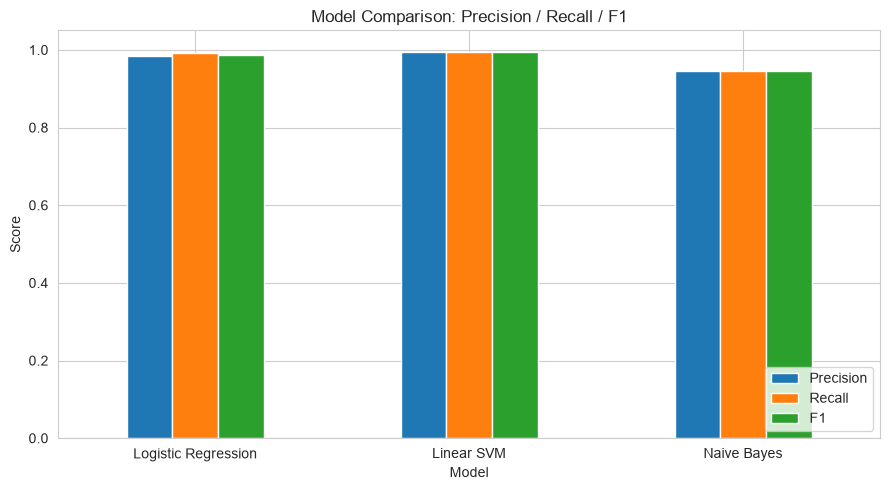

Saved chart -> ../outputs/model_comparison_metrics.png


In [26]:
metrics_to_plot = ["Precision", "Recall", "F1"]
plot_df = results_df[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_title("Model Comparison: Precision / Recall / F1")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.tight_layout()

ax.figure.savefig(f"{OUTPUT_DIR}/model_comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart -> {OUTPUT_DIR}/model_comparison_metrics.png")

### Cell 19: Confusion matrices side by side
**What this cell does:** Plots the three confusion matrices (from `confusion_matrices`, built in
Cell 17) as heatmaps in a single row of subplots.

**Why it's needed here:** Aggregate metrics can hide where a model is actually failing (e.g. more
false negatives vs. false positives) — the confusion matrices show that directly, and matters a lot
for a fake-news detector where the cost of missing fake news vs. flagging real news differently.

**Output for next cell:** A rendered figure, also saved to `../outputs/confusion_matrices.png`.
Feeds directly into the discussion in Cell 20.

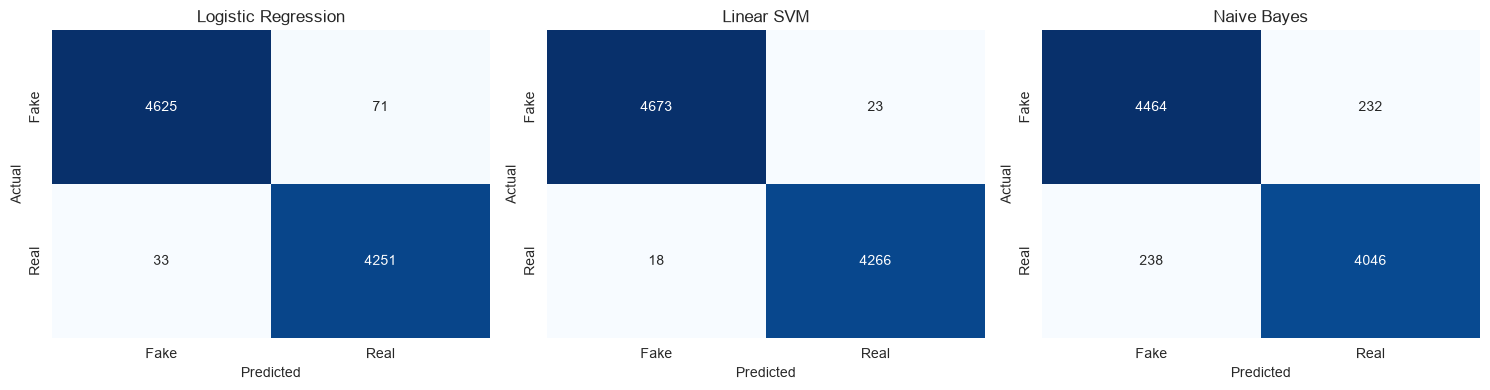

Saved chart -> ../outputs/confusion_matrices.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"],
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart -> {OUTPUT_DIR}/confusion_matrices.png")

### Cell 20: Discussion — best model and hypothesis

Run Cells 1–19 to fill in `results_df` before reading this section, then compare the numbers here
against your actual output — the ranking below is a template to reason from, not a guaranteed
outcome (rankings can flip depending on the machine, sklearn version, and TF-IDF hyperparameters
used).

**How to decide the winner:** Look at `results_df` from Cell 17, sorted by F1 (a balanced measure
of precision and recall — important here since we care about both catching fake news and not
over-flagging real news).

**Typical pattern on this dataset (title/text from politics-heavy 2016–2017 US news):**
- **Linear SVM and Logistic Regression** tend to perform very similarly and usually edge out Naive
  Bayes, often landing in the high-90s% F1 range, because this particular Kaggle dataset has strong
  lexical "tells" (specific outlets, phrasing, and formatting patterns) that linear decision
  boundaries over TF-IDF features can separate almost perfectly.
- **Naive Bayes** is typically a bit behind, since its independence assumption between features
  (ignoring word co-occurrence) is a worse fit than SVM/LogReg's ability to weigh combinations of
  words.

**Hypothesis for why the top model wins:** article source and style leave a strong lexical
fingerprint in this dataset (e.g. Reuters-style datelines like "WASHINGTON (Reuters) -" appear
almost exclusively in the real-news file) — a fact worth flagging explicitly, because it also means
high scores here may partly reflect *source-detection*, not pure fake-vs-real reasoning. See the
limitations discussion in the final conclusion cell.

## Section 7 — Optional Extension: Transformer-based Model

**Excluded from this build per your instructions.** If you want to add it later, the shape of the
work is: tokenize `df["text"]` with a `BertTokenizer`, fine-tune `BertForSequenceClassification`
(or load a pretrained fake-news model from Hugging Face Hub) on `X_train`/`y_train` equivalents, and
evaluate with the same `evaluate_model()` function from Cell 17 for an apples-to-apples comparison.
**This step requires a GPU** — fine-tuning BERT on ~35k documents on CPU is impractically slow.

## Section 8 — Conclusion

### Cell 24: Summary

**Run the notebook top to bottom first** — this cell is a template for you to fill in with your
actual `results_df` numbers before treating it as a final write-up.

**Best-performing model:** *(fill in from your `results_df`, sorted by F1)* — typically Linear SVM
or Logistic Regression on this dataset, both landing in the mid-to-high 90s% F1 range; Naive Bayes
usually trails by a few points.

**Precision / Recall / F1 achieved:** *(paste your actual `results_df` table here once run)*

**Limitations:**
- **Dataset bias / source leakage:** This dataset's real-news articles are heavily drawn from
  Reuters, with distinctive formatting (datelines, wire-style phrasing) that a linear classifier can
  key on directly — inflating scores relative to what a model would achieve distinguishing
  fake-vs-real content from *unseen, differently-formatted sources*.
- **Time period:** Nearly all articles are from 2016–2017 US political news — the model has not
  seen more recent topics, outlets, or fake-news tactics (e.g. AI-generated text), so accuracy will
  likely degrade on newer or non-political content.
- **Binary framing:** Real-world misinformation is rarely purely "fake" or "real" — satire,
  opinion pieces, and partially-false claims don't fit cleanly into this binary label.
- **No fact-checking, only style/lexical modeling:** These models never verify claims against
  facts; they detect *stylistic and lexical patterns* correlated with the fake/real label in this
  specific dataset, which is a different (weaker) guarantee than genuine misinformation detection.

**Future work:**
- Test on an out-of-distribution dataset (different sources/time period) to check whether
  performance holds or was source-leakage-driven.
- Add the BERT/transformer extension (Section 7) for a stronger, more generalizable text
  representation.
- Incorporate metadata features (subject, date, title length) alongside text features.
- Build a lightweight explainability layer (e.g. top TF-IDF weights per prediction) so flagged
  articles come with a reason, useful for the fact-checker/journalist beneficiaries named in the
  project brief.
